# Kepler-51 planetary system in the light of the PhotoRing effect
## Reproducing the figures of Numpaque et al. (2026)

This notebook contains the code for reproducing the figures in the paper:

> S. Numpaque, J.I. Zuluaga, D. Kipping and J.A. Alvarado "Asterodensity profile analysis of the Kepler-51 planetary system:1
a case study on the detection of exoplanetary rings via the PhotoRing effect", in preparation.

For detailed explanations see the GitHub repository: [https://github.com/seap-udea/PRisma](https://github.com/seap-udea/PRisma).

## Preparing the environment

In [1]:
# ── Bootstrap: make the repository packages importable without installation ──
import sys, pathlib
_HERE = pathlib.Path.cwd()
_cands = [_HERE, *_HERE.parents]
_REPO = next((c for c in _cands if (c / "pipeline" / "photoring").is_dir() and (c / "pipeline" / "exorings").is_dir()), _HERE.parent)
for _p in (str(_REPO / "pipeline"), str(_REPO)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
print("repo root:", _REPO)


repo root: /Users/jzuluaga/dev/PRisma


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

import photoring as pr
import photoring.plotting as plot
from photoring import literature, contour
from photoring.io import load_observables, load_run

# The manuscript's look: saturated palette, LaTeX, 95% corner intervals.
plot.apply_style(plot.PAPER_STYLE)

# ── Select the system (paper name → pipeline case directory) ──────────────
SYSTEM = "kepler51"
CASE = {"kepler51": "kepler_51"}[SYSTEM]

paths = pr.CasePaths(CASE, pipeline_dir=_REPO / "pipeline")
RESULTS = paths.results_dir("exorings")
IMG = pathlib.Path(_REPO / "papers" / SYSTEM / "figures")
IMG.mkdir(parents=True, exist_ok=True)

print("SYSTEM:", SYSTEM)
print("CASE:  ", CASE)
print("results:", RESULTS)
print("figures:", IMG)


SYSTEM: kepler51
CASE:   kepler_51
results: /Users/jzuluaga/dev/PRisma/pipeline/kepler_51/results/exorings
figures: /Users/jzuluaga/dev/PRisma/papers/kepler51/figures


## 1. Configuration — the adopted runs

The manuscript's ring-geometry figures use the **fully free** model
($f_e,\ i_R,\ \theta,\ p,\ \tau,\ \rho_{\star,\rm true},\ b$ all sampled) with the likelihood
$\mathcal{L}_{\rm KDE} = (\delta,\ T_{14},\ \rho_{\star,\rm obs})$, nested sampling at
$N_{\rm live}=1200$ and $\Delta\ln Z = 0.01$, and $N_{\rm KDE}=5000$ training samples.

That combination was adopted because it is the only one in the retrieval suite that
reproduces the **full** set of transit observables — including the ones left out of the
likelihood. Simpler configurations fit their own likelihood observables but mispredict the
durations.

Runs are loaded from ``pipeline/<CASE>/results/exorings/``. Edit ``SYSTEM`` and
``RETRIEVAL_SETUP`` below to switch target / configuration.


In [3]:
# ── Select the retrieval setup (filename stem after "{CASE}_{planet}_") ───
# Available setups live under pipeline/<CASE>/results/exorings/*.npz
RETRIEVAL_SETUP = (
    "NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01"
    "_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE"
)
PLANETS = ["b", "d"]

print("RETRIEVAL_SETUP:")
print(" ", RETRIEVAL_SETUP)

runs = {}
npz_used = []
for pl in PLANETS:
    npz = RESULTS / f"{CASE}_{pl}_{RETRIEVAL_SETUP}.npz"
    npz_used.append(npz)
    if not npz.exists():
        print(f"MISSING: {npz}")
        continue
    runs[pl] = load_run(npz)
    r = runs[pl]
    print(f"planet {pl}: ndim={len(r['param_names'])}  lnZ={r['logz']:.3f}  "
          f"L_KDE={r['kde_obs']}  n={len(r['chain'])}")
    print(f"  <- {npz.name}")

ttv = {pl: load_observables(paths.observables_file(pl)) for pl in PLANETS}
rho_true_samples = np.loadtxt(paths.rho_true_samples) / 1000.0   # kg/m^3 -> g/cm^3
print("\nTTV observables loaded:", {k: len(v["delta"]) for k, v in ttv.items()})

RUN_VERSION = plot.run_version_id(npz_used)
print("RUN_VERSION:", RUN_VERSION)


RETRIEVAL_SETUP:
  NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE
planet b: ndim=7  lnZ=2.002  L_KDE=['delta', 'T14', 'rho_obs']  n=16631
  <- kepler_51_b_NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE.npz
planet d: ndim=7  lnZ=1.958  L_KDE=['delta', 'T14', 'rho_obs']  n=14994
  <- kepler_51_d_NS_exorings_kde_delta-T14-rho_obs_nlive1200_dlogz0.01_NKDE5000_seed2026_rhoFREE_bFREE_tauFREE_pFREE.npz

TTV observables loaded: {'b': 17756, 'd': 39002}
RUN_VERSION: 2026073023


## 6. Inferred ring geometries

**Manuscript figures:** `final_planetb_panel_.png`, `final_planetd_panel_.png`.

Per planet: the joint posterior over ring and nuisance parameters, with a sky-plane sketch of
the inferred ring system at the posterior medians inset in the corner plot's free upper-right
triangle. The black disk is the planet, the elliptical annulus the ring.

The corner is drawn by `dynesty` from the **weighted** nested-sampling output, and the titles
report its default 95% credible interval. What to read off it:

- **$f_e$** lands well inside its uniform prior at both edges — a genuine constraint, not a
  prior artefact — and far below the prograde stability bound near $0.5\,R_{\rm Hill}$. The
  values are comparable to Saturn's main rings, which reach $\approx 2.3\,R_{\rm Saturn}$.
- **The $f_e$–$p$ anti-correlation** is the most persistent feature of the whole retrieval
  suite. The effective occulting area is $A_{\rm eff} = \pi R_p^2 + A_{\rm ring}$, so any
  $(p, f_e)$ pair preserving $A_{\rm eff}$ gives an identical transit depth and the sampler
  explores that iso-depth surface freely.
- **$i_R$ and $\theta$** favour moderately inclined rings. Because the prior on $i_R$ is
  already $\propto \sin i_R$ (isotropic, hence edge-on-favouring), any departure *from the
  prior shape* measures the information the data actually contributed.
- **$b$ and $\rho_{\star,\rm true}$** are nuisance parameters, sampled here rather than fixed.
  Their posteriors sit in tension with the external constraints, which is why the manuscript
  reports these as model-conditional geometric solutions rather than as a revision of the
  system's orbital architecture or the star's properties.


In [4]:
# Corner / ring-panel figures come from photoring.plotting
# (plot_results_panel_inset, plot_results_panel_reduced_inset, …).


-> /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/final_planetb_panel_.png
-> /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/final_planetd_panel_.png


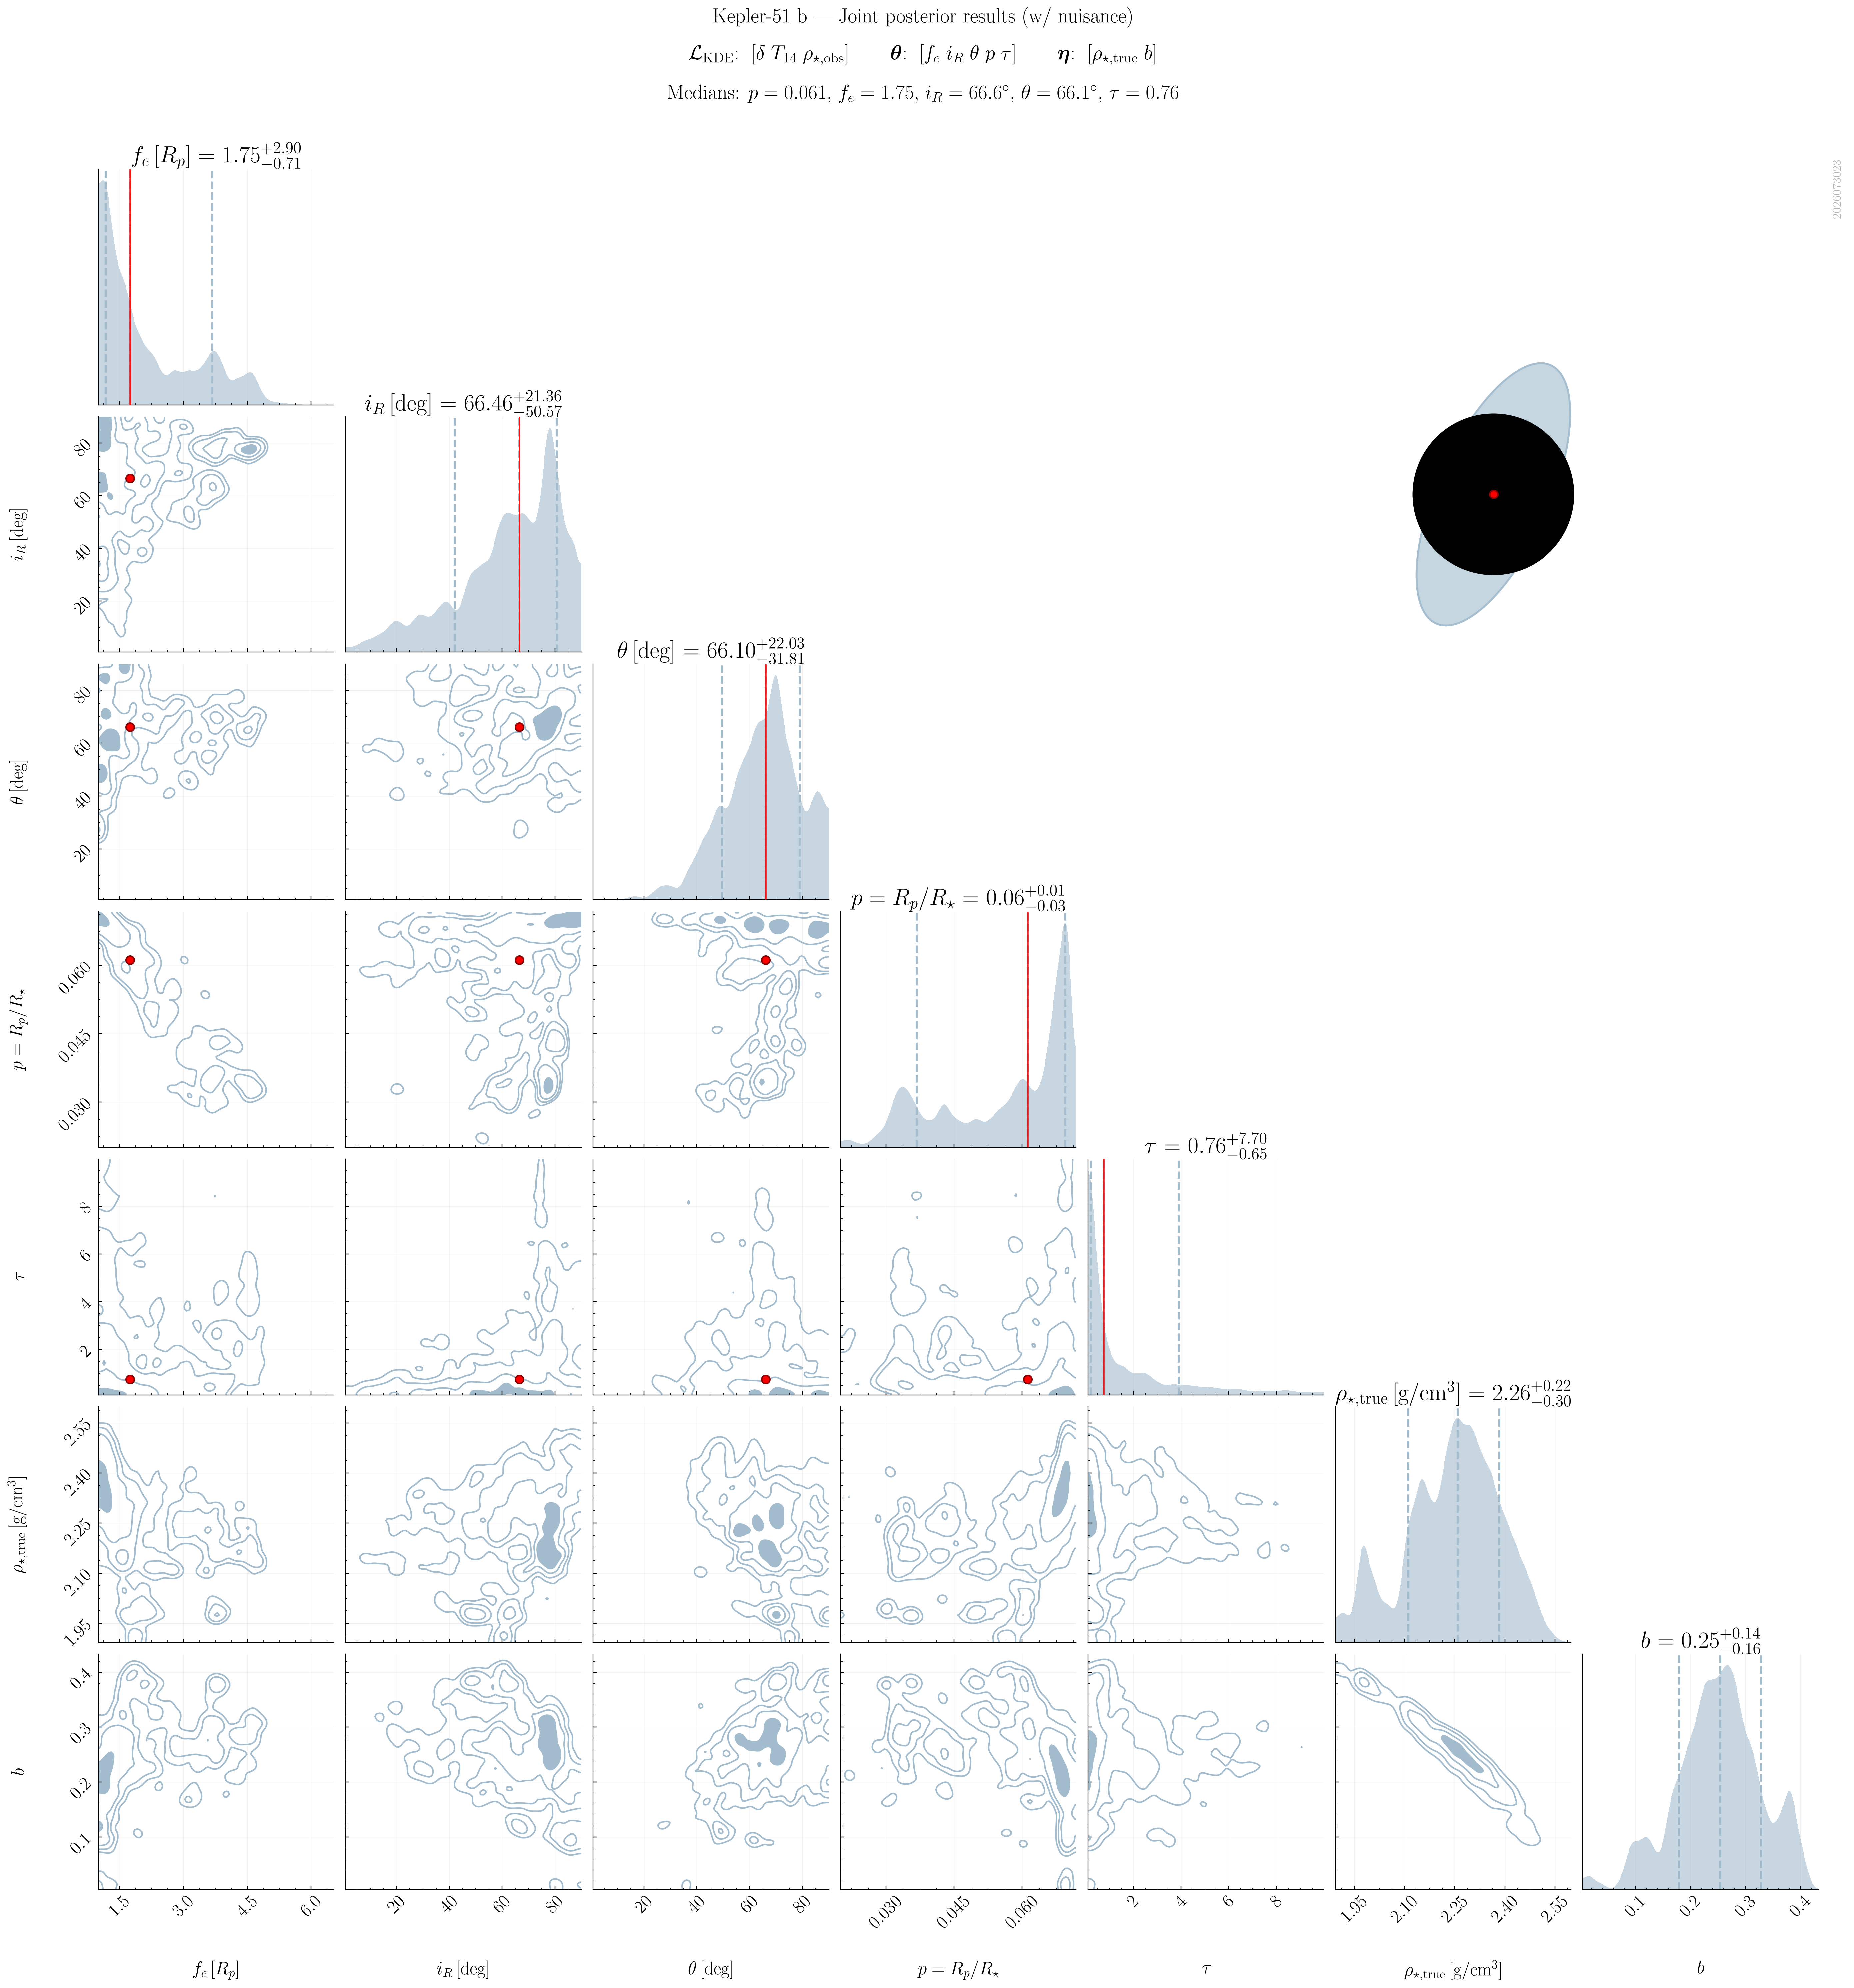

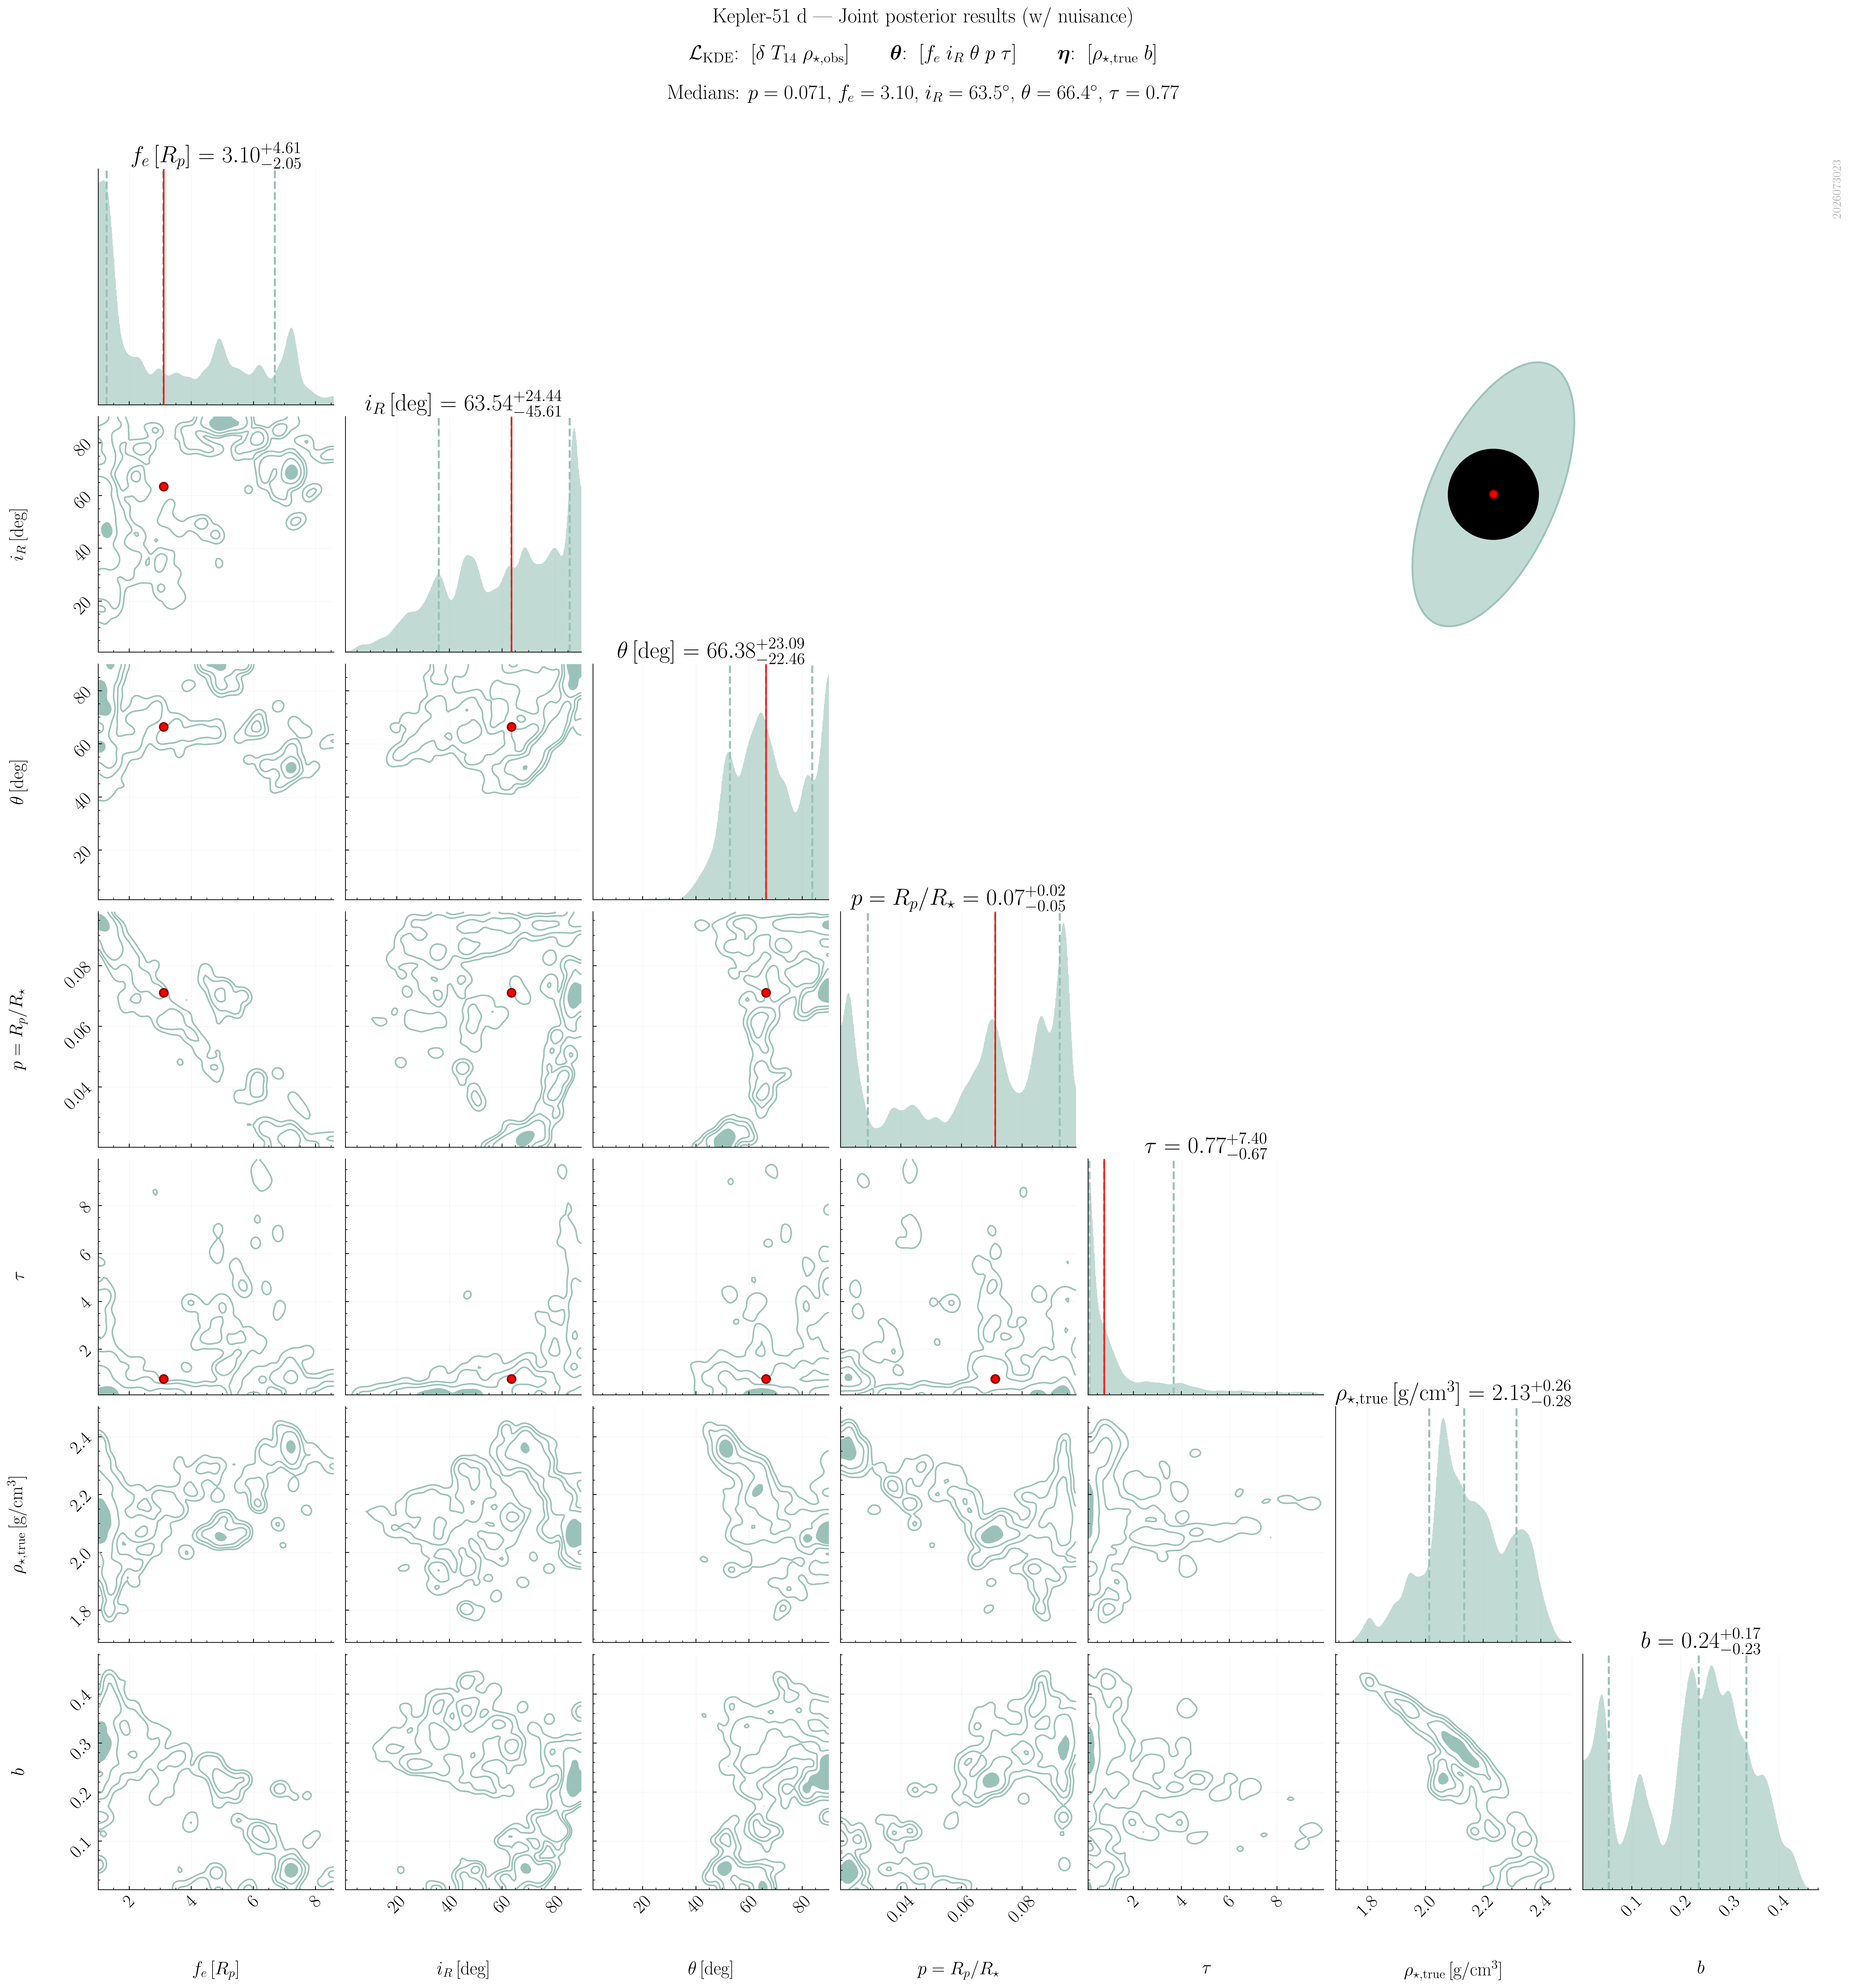

In [5]:
PANEL_NAME = {"b": "final_planetb_panel_.png", "d": "final_planetd_panel_.png"}

for pl, run in runs.items():
    fig = plot.plot_results_panel_inset(run)
    out = IMG / PANEL_NAME[pl]
    plot.add_run_version_label(fig, RUN_VERSION)
    fig.savefig(out, dpi=plot.STYLE["fig_dpi"], bbox_inches="tight")
    print("->", out)
    # plt.close(fig)


### Reduced Corner Plots
This section contains routines to plot the corner plots excluding nuisance parameters $\rho_{\star,\text{true}}$ and $b$.

In [6]:
# Reduced corner + ring inset: plot.plot_results_panel_reduced_inset


-> /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/final_planetb_panel_reduced.png


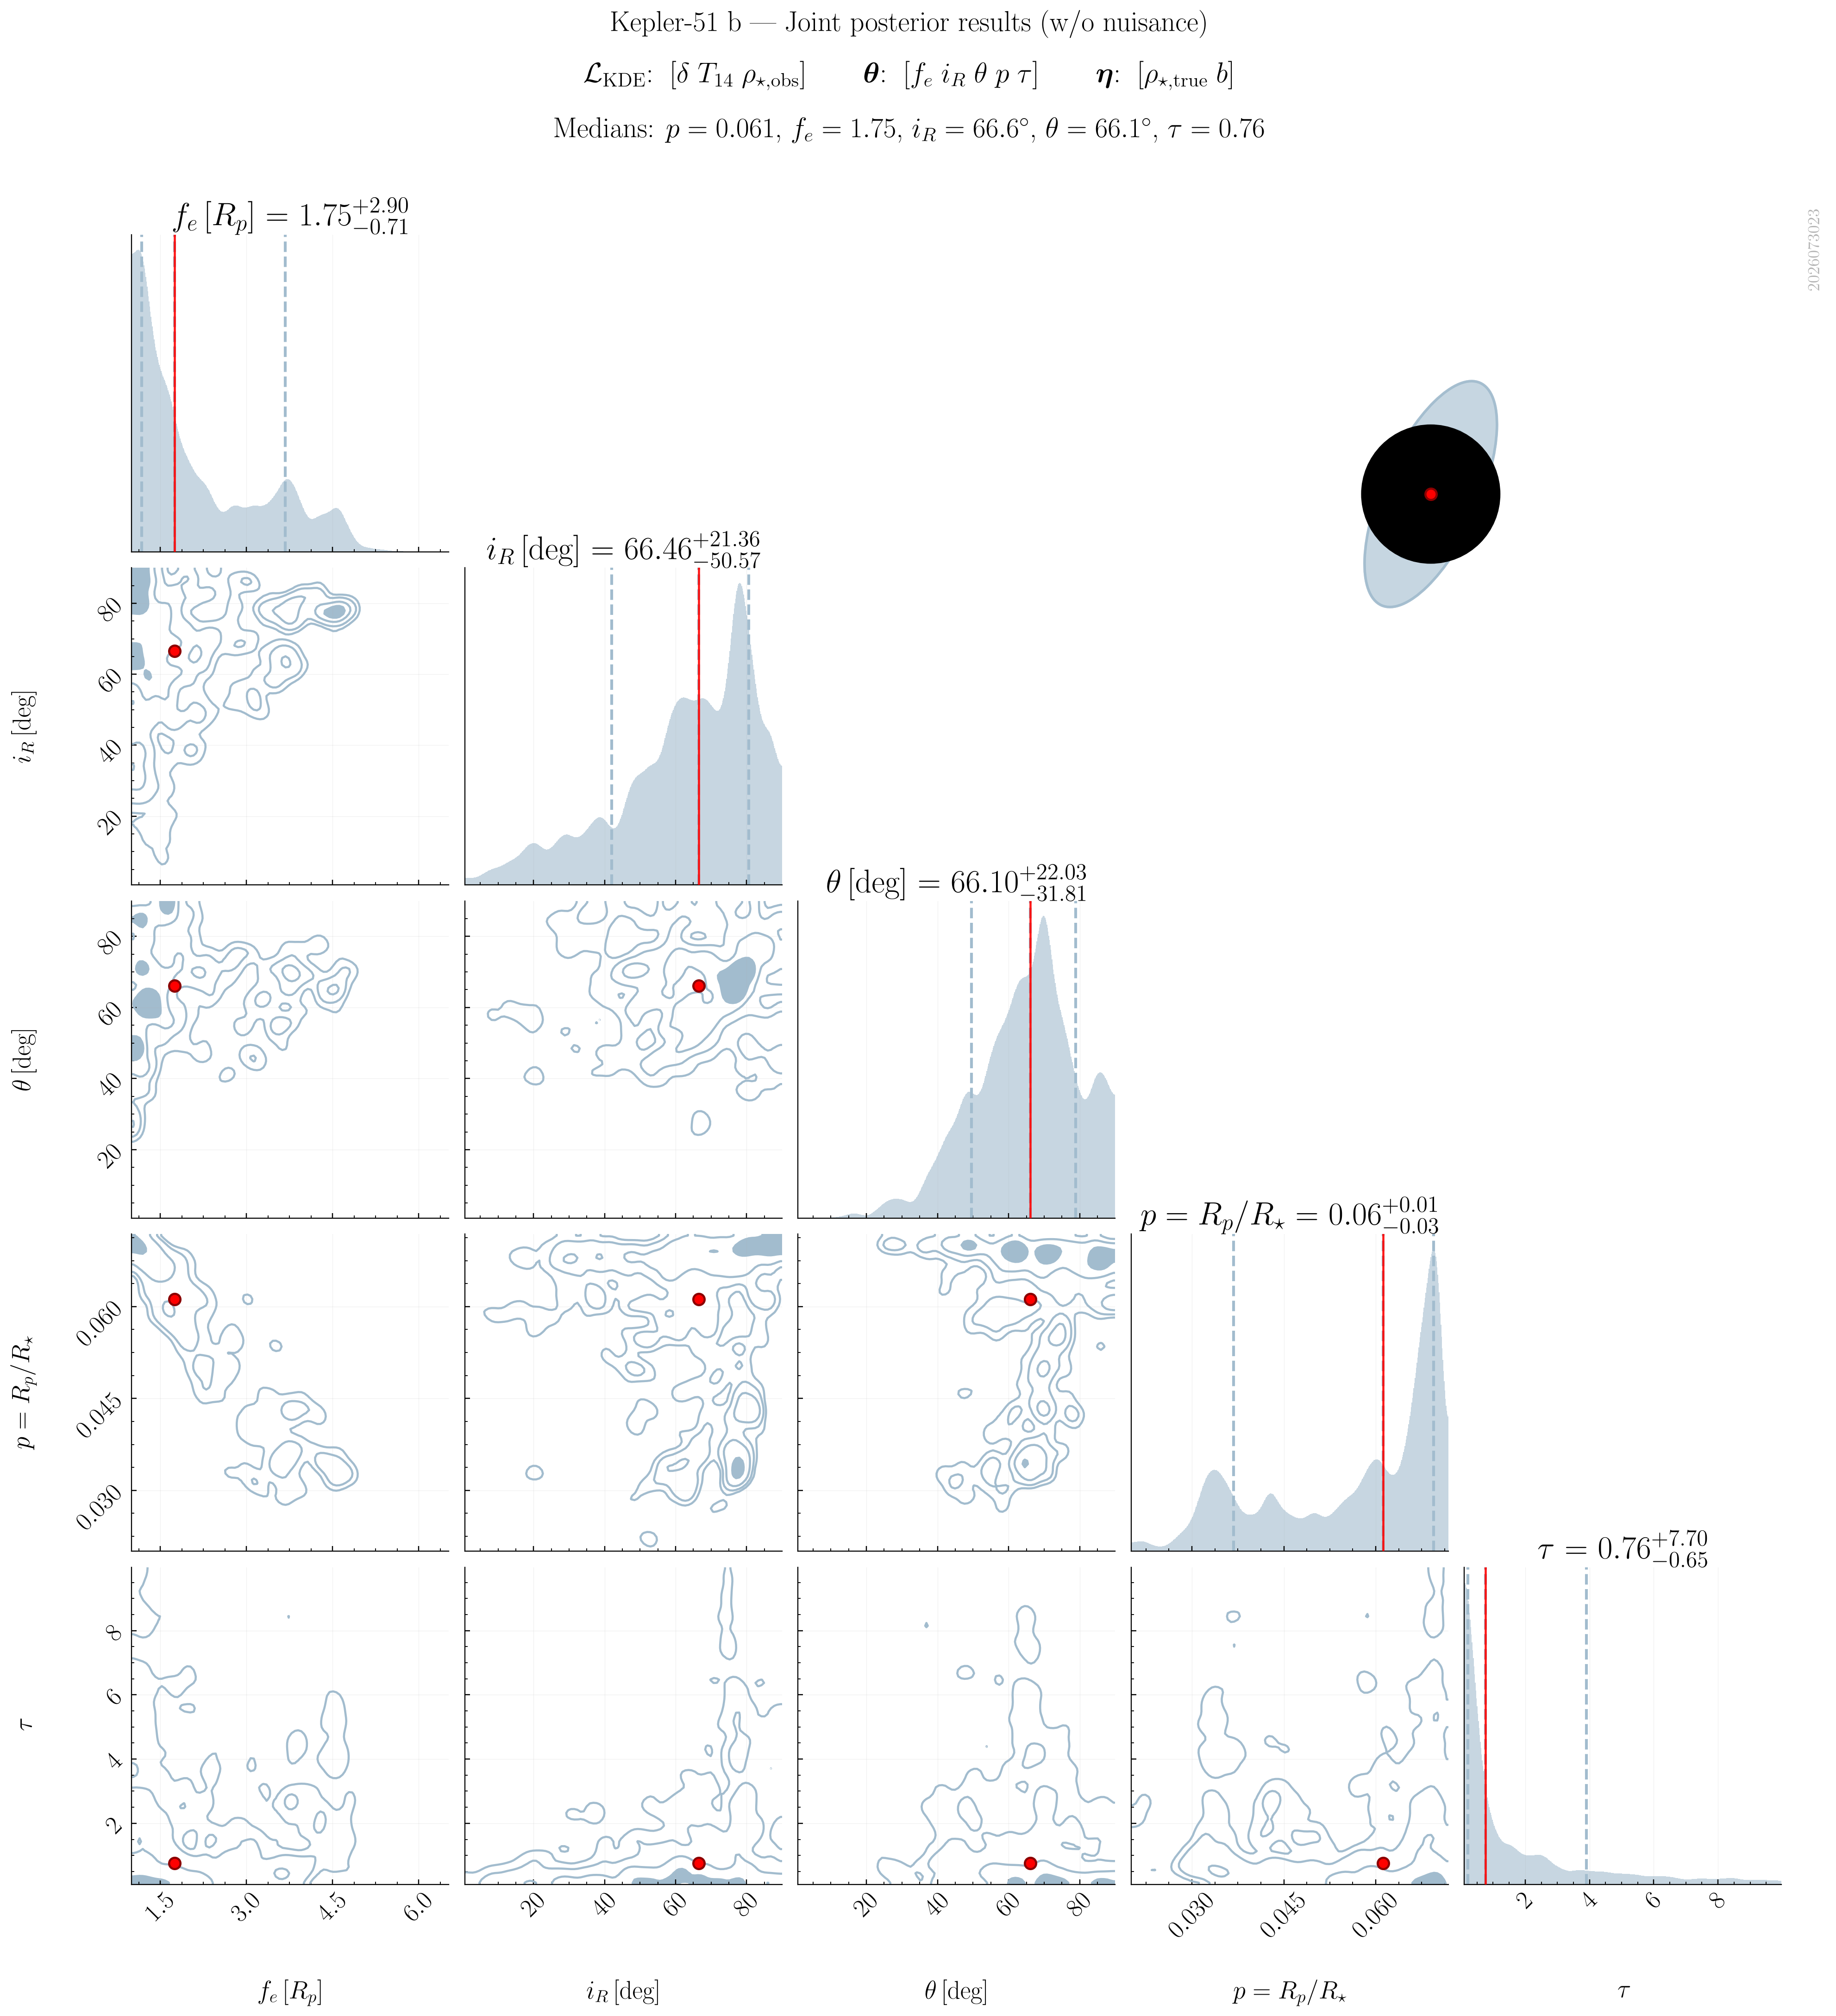

-> /Users/jzuluaga/dev/PRisma/papers/kepler51/figures/final_planetd_panel_reduced.png


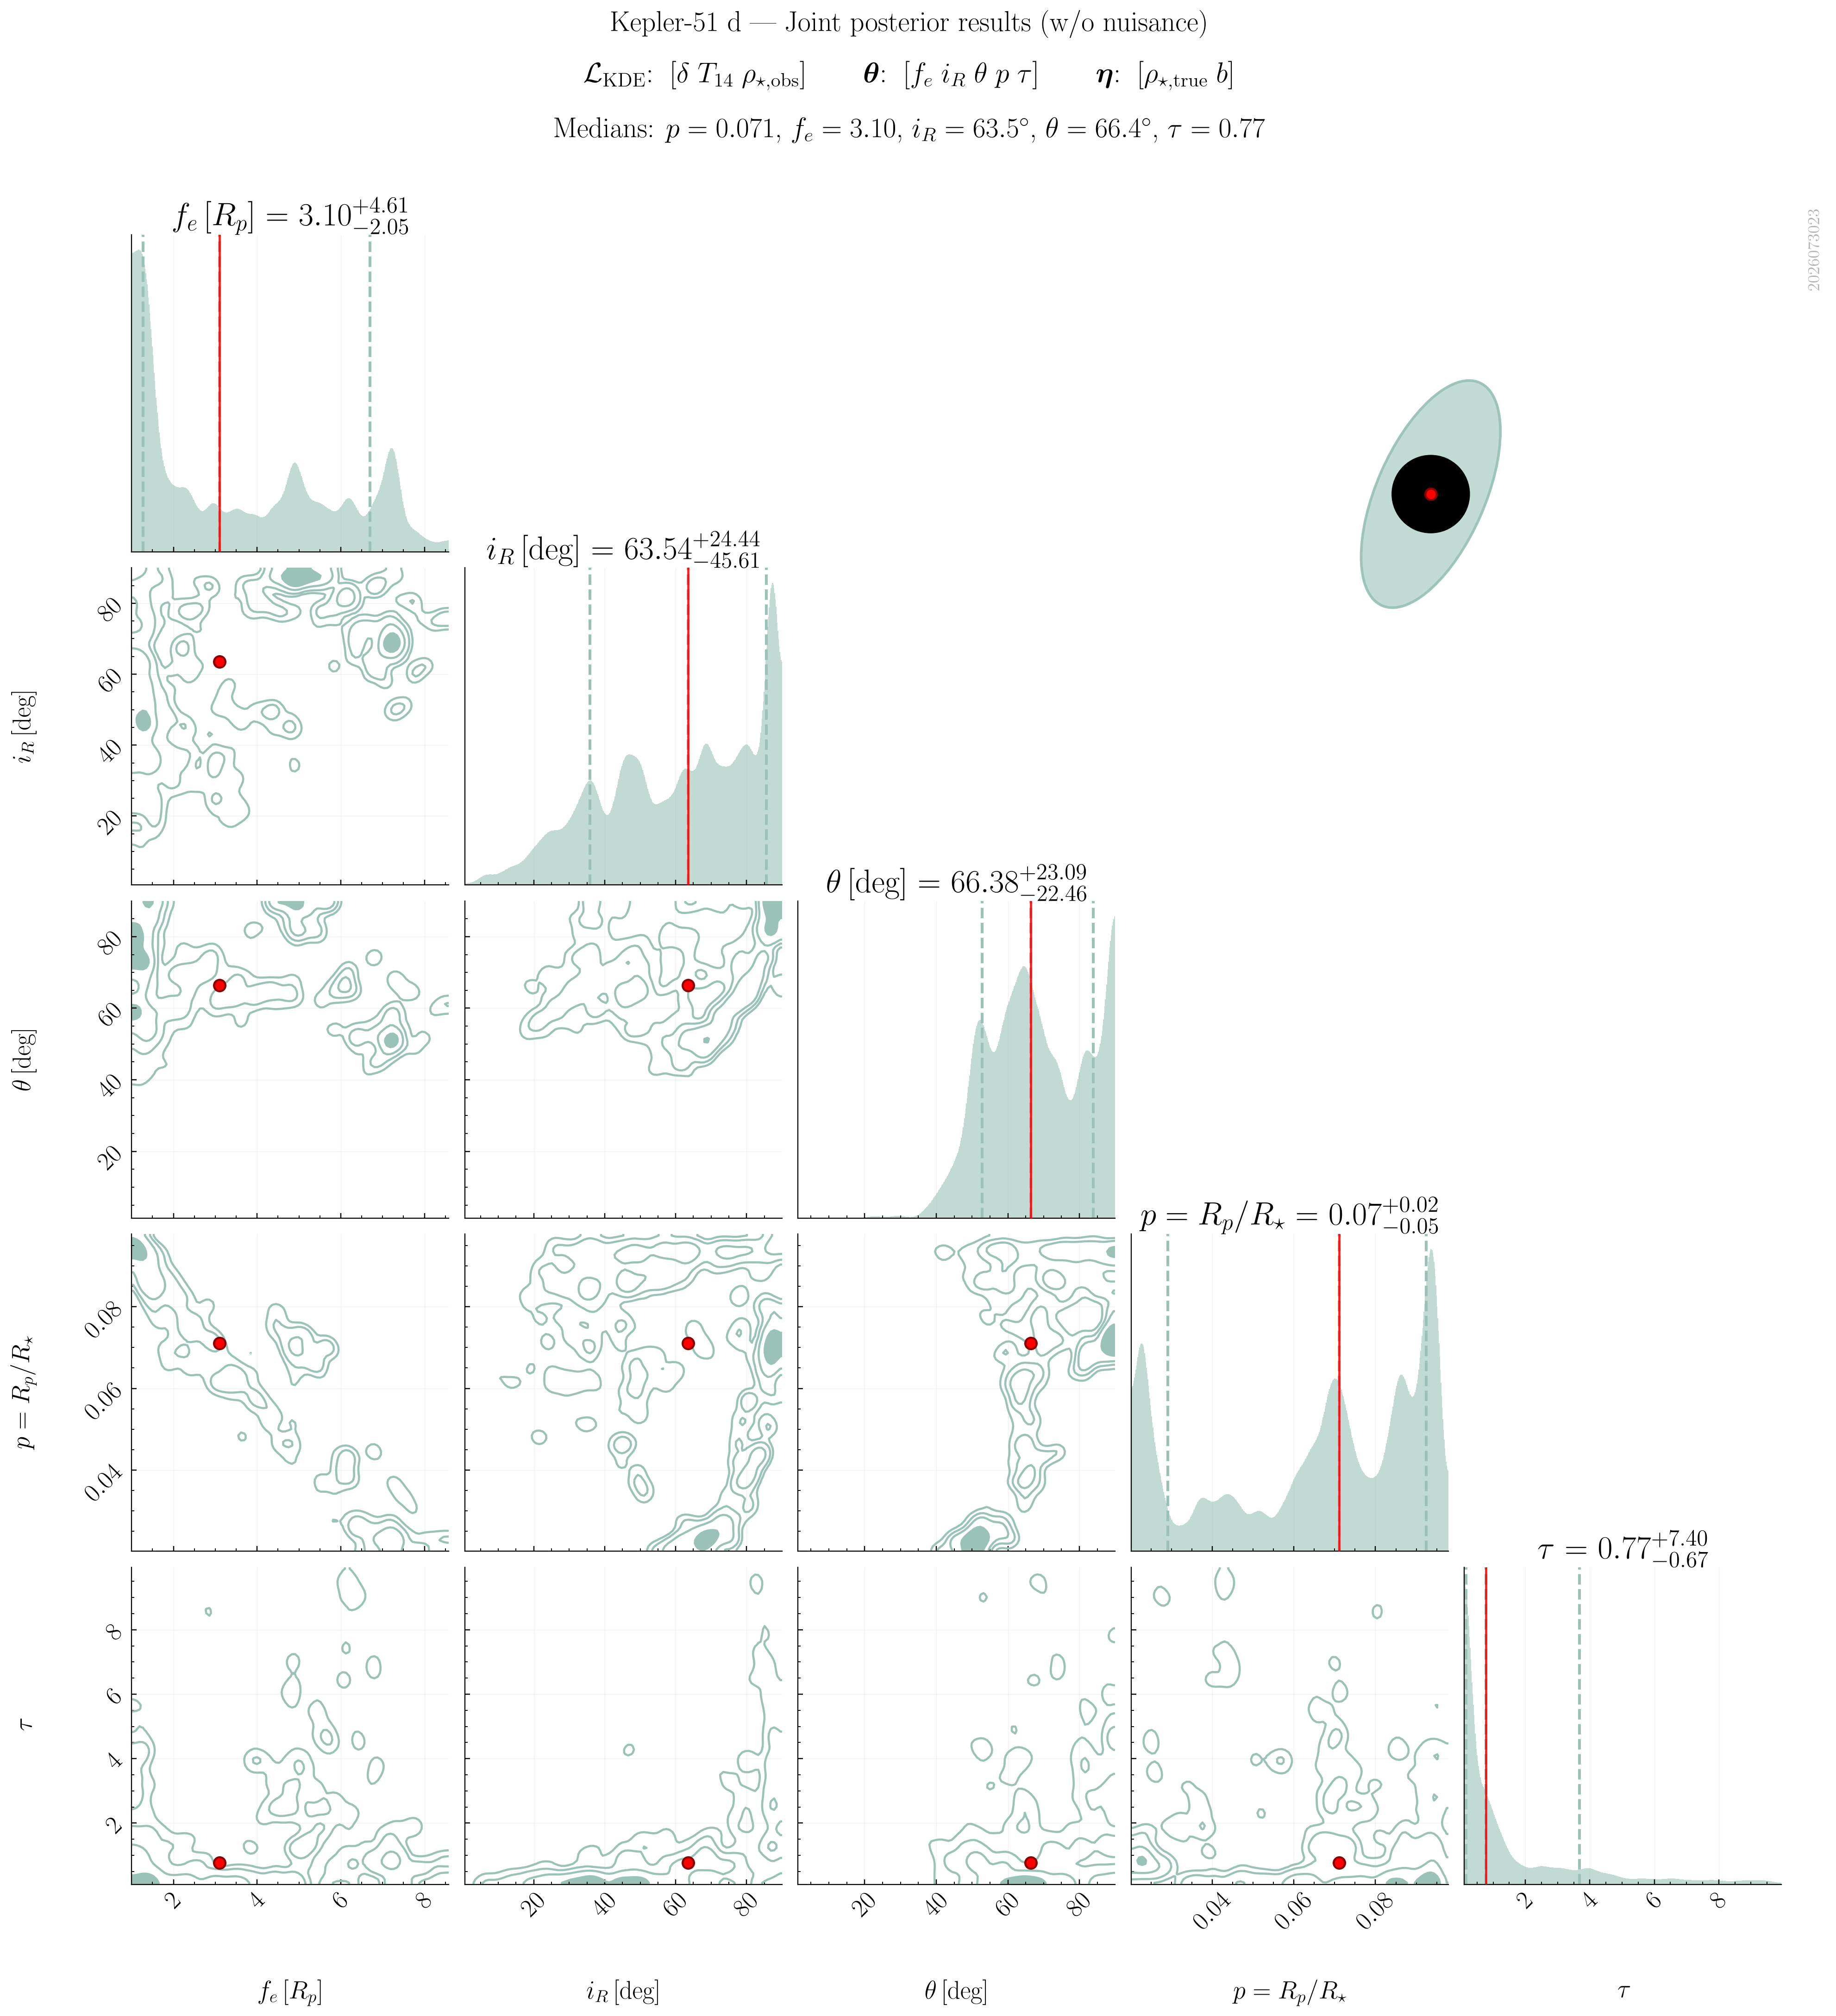

In [7]:
for pl in ["b", "d"]:
    fig_reduced = plot.plot_results_panel_reduced_inset(runs[pl], title=True)
    out_reduced = IMG / f"final_planet{pl}_panel_reduced.png"
    plot.add_run_version_label(fig_reduced, RUN_VERSION)
    fig_reduced.savefig(out_reduced, bbox_inches="tight", dpi=plot.STYLE["fig_dpi"])
    print("->", out_reduced)
    plt.show()
    #break
